# PixelCNN — Modèle Autorégressif sur FashionMNIST

Ce notebook implémente un **PixelCNN**, un modèle génératif autorégressif qui apprend à générer des images **pixel par pixel**, de gauche à droite et de haut en bas. Chaque pixel est prédit en fonction de tous les pixels précédents uniquement (pas de pixels futurs), grâce à des **convolutions masquées**.

Le modèle est entraîné sur **FashionMNIST** redimensionné en 16×16 avec une palette réduite à **4 niveaux de gris**, ce qui transforme la génération en un problème de **classification multi-classes** par pixel.

## 1. Imports et hyperparamètres

Importation des bibliothèques PyTorch, torchvision et matplotlib, puis définition des hyperparamètres globaux :

| Paramètre | Valeur | Rôle |
|---|---|---|
| `IMAGE_SIZE` | 16 | Taille de l'image (16×16 pixels) |
| `PIXEL_LEVELS` | 4 | Nombre de niveaux de gris (quantification) |
| `N_FILTERS` | 128 | Nombre de filtres dans les couches conv |
| `RESIDUAL_BLOCKS` | 5 | Nombre de blocs résiduels dans le modèle |
| `BATCH_SIZE` | 128 | Taille des mini-batchs |
| `EPOCHS` | 5 | Nombre d'epochs d'entraînement |

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
# Parameters
IMAGE_SIZE = 16
PIXEL_LEVELS = 4
N_FILTERS = 128
RESIDUAL_BLOCKS = 5
BATCH_SIZE = 128
EPOCHS = 5
DEVICE =torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Préparation des données

Chargement du dataset **FashionMNIST** avec un pipeline de transformations :
1. **Resize** : les images 28×28 sont redimensionnées en 16×16
2. **ToTensor** : conversion en tenseur float dans [0, 1]
3. **Quantification** : les valeurs continues sont discrétisées en `PIXEL_LEVELS` niveaux entiers (0, 1, 2 ou 3) via une division entière

Le `DataLoader` gère le chargement par mini-batchs avec mélange aléatoire (`shuffle=True`).

In [11]:
# Data Preparation
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).float() // (256 // PIXEL_LEVELS))
])
path= r"./data"
dataset = datasets.FashionMNIST(root=path, train=True, download=True, transform=transform)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

## 3. Convolution masquée (`MaskedConv2d`)

Composant clé du PixelCNN. C'est une `Conv2d` standard dont on **masque certains poids** pour garantir la propriété autoregressive :

- **Masque de type A** (première couche) : le pixel courant est masqué → la prédiction du pixel `(i,j)` ne dépend que des pixels *strictement* précédents.
- **Masque de type B** (couches suivantes) : le pixel courant est inclus → permet à l'information de se propager tout au long du réseau.

Le masque met à zéro tous les poids correspondant aux pixels à droite ou en dessous du pixel central dans le champ récepteur, empêchant ainsi toute "fuite" d'information future.

In [12]:
# Masked Convolution Layer
class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.register_buffer('mask', self.weight.data.clone())
        _, _, h, w = self.weight.size()
        self.mask.fill_(1)
        self.mask[:, :, h // 2, w // 2 + (mask_type == 'B'):] = 0
        self.mask[:, :, h // 2 + 1:] = 0

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)

## 4. Bloc résiduel (`ResidualBlock`)

Bloc de type **ResNet** adapté au PixelCNN. Il est composé de :
1. `ReLU` + `Conv 1×1` : réduction du nombre de filtres par 2 (bottleneck)
2. `ReLU` + `MaskedConv2d type B` 3×3 : convolution masquée sur les features réduites
3. `ReLU` + `Conv 1×1` : restauration du nombre de filtres d'origine

La **connexion résiduelle** (`x + block(x)`) permet de conserver le gradient et d'entraîner des réseaux plus profonds sans dégradation. L'utilisation de masques de type B (vs A) est correcte ici car ce ne sont pas les premières couches du réseau.

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, filters):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(filters, filters // 2, kernel_size=1),
            nn.ReLU(),
            MaskedConv2d('B', filters // 2, filters // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(filters // 2, filters, kernel_size=1)
        )

    def forward(self, x):
        return x + self.block(x)

## 5. Architecture du modèle PixelCNN

Assemblage du modèle complet en séquence :

1. **`MaskedConv2d A` 7×7** : première couche, champ récepteur large, masque A (exclut le pixel courant)
2. **5× `ResidualBlock`** : blocs résiduels pour enrichir les représentations internes
3. **`ReLU` + `MaskedConv2d B` 1×1** × 2 : raffinement point à point des features
4. **`Conv2d` 1×1 → `PIXEL_LEVELS` canaux** : couche de sortie produisant les **logits** pour chacun des 4 niveaux possibles par pixel

En sortie, pour chaque pixel on obtient un vecteur de 4 logits → la classe prédite correspond au niveau de gris le plus probable.

In [14]:
class PixelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            MaskedConv2d('A', 1, N_FILTERS, kernel_size=7, padding=3),
            *[ResidualBlock(N_FILTERS) for _ in range(RESIDUAL_BLOCKS)],
            nn.ReLU(),
            MaskedConv2d('B', N_FILTERS, N_FILTERS, kernel_size=1),
            nn.ReLU(),
            MaskedConv2d('B', N_FILTERS, N_FILTERS, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(N_FILTERS, PIXEL_LEVELS, kernel_size=1)
        )

    def forward(self, x):
        return self.model(x)

model = PixelCNN().to(DEVICE)

## 6. Boucle d'entraînement

Entraînement du modèle avec :
- **Optimiseur** : Adam (lr = 0.0005)
- **Fonction de perte** : `CrossEntropyLoss` — chaque pixel est traité comme un problème de classification à 4 classes

À chaque batch :
1. Les images sont chargées sur le device et mises en forme : `inputs` float avec un canal (`[B, 1, H, W]`), `targets` entiers longs (`[B, H, W]`)
2. Le modèle produit des logits `[B, 4, H, W]`
3. La CrossEntropy compare logits et cibles pixel par pixel
4. Rétropropagation et mise à jour des poids

La perte moyenne par epoch est affichée pour suivre la convergence.

In [15]:
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()
# Training Loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, _ in tqdm(data_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):

        images = images.to(DEVICE).squeeze(1)
        optimizer.zero_grad()
        inputs = images.float().unsqueeze(1)     # [batch, 1, H, W]
        targets = images.long()                  # [batch, H, W]
        outputs = model(inputs)                  # [batch, PIXEL_LEVELS, H, W]
        loss = criterion(outputs, targets)       # CrossEntropy expects float inputs and long targets
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1/5: 100%|██████████| 469/469 [00:24<00:00, 19.36it/s]


Epoch 1, Loss: 0.4346


Epoch 2/5: 100%|██████████| 469/469 [00:23<00:00, 19.62it/s]


Epoch 2, Loss: 0.3346


Epoch 3/5: 100%|██████████| 469/469 [00:24<00:00, 18.76it/s]


Epoch 3, Loss: 0.3252


Epoch 4/5: 100%|██████████| 469/469 [00:24<00:00, 19.20it/s]


Epoch 4, Loss: 0.3199


Epoch 5/5: 100%|██████████| 469/469 [00:23<00:00, 19.91it/s]

Epoch 5, Loss: 0.3157


## 7. Génération d'images

Fonction `generate_images` : génère des images de zéro en mode **autorégressif**, pixel par pixel.

**Processus** :
1. On part d'une image vide (tous les pixels à 0)
2. Pour chaque position `(row, col)` dans l'ordre de lecture :
   - On passe l'image partielle dans le modèle → logits pour la position courante
   - On divise par la **température** (contrôle la diversité : < 1 = plus conservateur, > 1 = plus aléatoire)
   - On applique un `softmax` pour obtenir une distribution de probabilité
   - On **échantillonne** un niveau de gris via `multinomial`
3. Le pixel généré est inséré dans l'image, qui sert de contexte pour les pixels suivants

Les images générées sont normalisées dans [0, 1] pour l'affichage.

In [16]:
def generate_images(model, num_images, temperature=1.0):
    model.eval()
    generated = torch.zeros(num_images, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    with torch.no_grad():
        for row in range(IMAGE_SIZE):
            for col in range(IMAGE_SIZE):
                logits = model(generated.float())[:, :, row, col] / temperature
                probs = torch.softmax(logits, dim=-1)
                generated[:, 0, row, col] = torch.multinomial(probs, 1).squeeze(-1)
    return generated.cpu().numpy() / PIXEL_LEVELS

# Generate sample images
sample_images = generate_images(model, num_images=10)
print("Generated images shape:", sample_images.shape)

Generated images shape: (10, 1, 16, 16)


## 8. Visualisation des images générées

Fonction `plot_generated_images` : affiche une grille d'images générées en niveaux de gris.

10 nouvelles images sont générées avec une température de `1.0` (sampling standard), puis affichées sur 2 lignes de 5 colonnes. Cela permet d'évaluer qualitativement la diversité et la cohérence visuelle des images produites par le modèle.

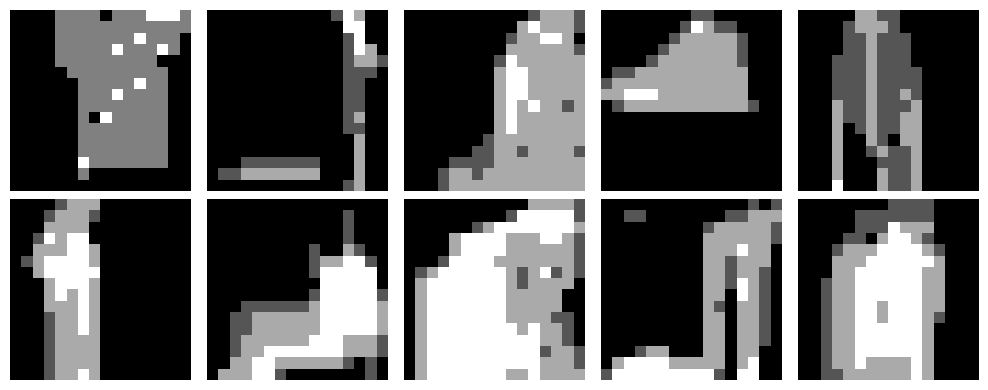

In [17]:
def plot_generated_images(images, n_cols=5):
    n_rows = (len(images) + n_cols - 1) // n_cols
    plt.figure(figsize=(2 * n_cols, 2 * n_rows))

    for idx, img in enumerate(images):
        plt.subplot(n_rows, n_cols, idx + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Generate sample images (assuming you've done this step already)
sample_images = generate_images(model, num_images=10, temperature=1.0)
# Plot generated images
plot_generated_images(sample_images)